# Ordinary Least Squares and Ridge Regression

普通最小二乘法：演示如何基于糖尿病数据集的单一特征，调用普通最小二乘(OLS)模型`LinearRegression`。使用部分子集数据完成训练，在测试集上评估模型效果，并可视化预测结果。
普通最小二乘法与岭回归的方差对比：通过多次在少量人工生成样本上拟合模型，展示：当数据稀疏或含大量噪声时，普通最小二乘法会出现高方差问题。而岭回归模型Ridge通过对回归系数施加惩罚（压缩系数取值），降低模型方差，从而得到更稳定的预测值。

## Data Loading and Preparation

加载糖尿病数据集。为简化操作，我们仅保留数据中的单一特征，随后将特征数据与标签划分为训练集和测试集。

In [29]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

X, y = load_diabetes(return_X_y=True)
X = X[:, [2]] # Use only one feature
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)

## Linear regression model

我们创建一个线性回归模型，并使用训练数据对其进行拟合。注意：模型默认会添加截距项，我们可通过设置fit_intercept参数来控制该功能是否开启。

In [30]:
from sklearn.linear_model import LinearRegression, Ridge

regressor = LinearRegression().fit(X_train, y_train)

## Model evaluation

我们在测试集上采用均方误差与决定系数两项指标评估模型性能。

In [31]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = regressor.predict(X_test)

print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

Mean squared error: 2548.07
Coefficient of determination: 0.47


## Plotting the results

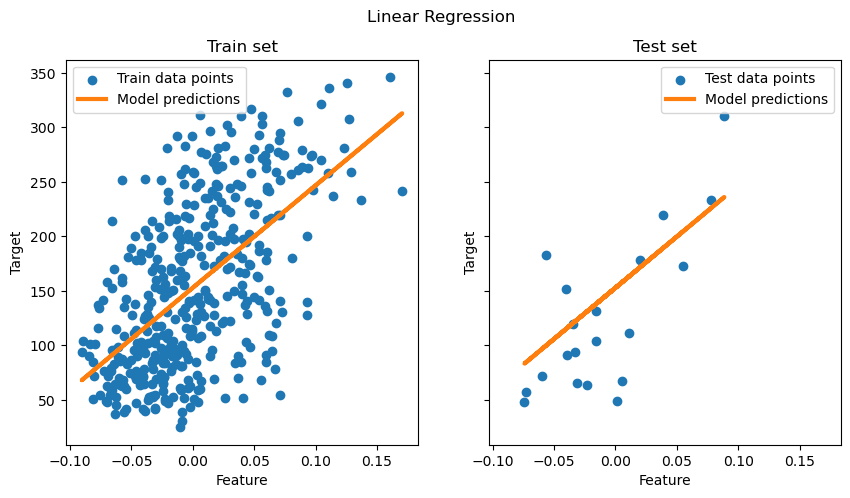

In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].scatter(X_train, y_train, label="Train data points")
ax[0].plot(
    X_train,
    regressor.predict(X_train),
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
ax[0].legend()

ax[1].scatter(X_test, y_test, label="Test data points")
ax[1].plot(
    X_test,
    y_pred,
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
ax[1].legend()

fig.suptitle("Linear Regression")

plt.show()

基于该单特征子集训练的普通最小二乘模型，会求解出使训练集均方误差最小的线性函数。我们可以通过测试集上的决定系数$R^2$与均方误差，判断模型泛化效果的优劣。在高维数据场景下，纯粹的普通最小二乘法极易发生过拟合，数据含噪声时该问题尤为突出。而岭回归、套索回归这类正则化方法能够缓解过拟合问题。

## Ordinary Least Squares and Ridge Regression Variance

接下来，我们采用小规模人工合成数据集，更直观地演示高方差问题。我们仅抽取两个数据样本，反复为其添加微小高斯噪声，分别重新拟合普通最小二乘模型与岭回归模型。我们将每次拟合得到的直线绘图展示，可以直观看到普通最小二乘拟合直线波动幅度极大；而岭回归因引入惩罚项，拟合结果会稳定许多。

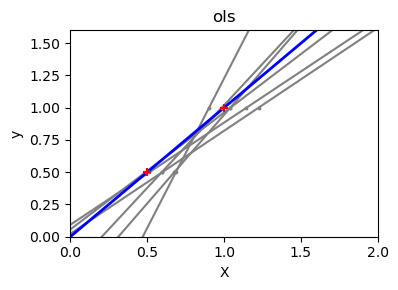

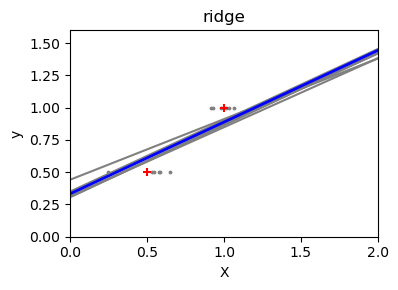

In [33]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn import linear_model

X_train = np.c_[0.5, 1].T
y_train = [0.5, 1]
X_test = np.c_[0, 2].T

np.random.seed(0)

classifiers = dict(
    ols=linear_model.LinearRegression(),
    ridge=linear_model.Ridge(alpha=0.1)
)

for name, clf in classifiers.items():
    fig, ax = plt.subplots(figsize=(4, 3))

    for _ in range(6):
        this_X = 0.1 * np.random.normal(size=(2,1)) + X_train
        clf.fit(this_X, y_train)

        ax.plot(X_test, clf.predict(X_test), color="gray")
        ax.scatter(this_X, y_train, s=3, c="gray", marker="o", zorder=10)

    clf.fit(X_train, y_train)
    ax.plot(X_test, clf.predict(X_test), linewidth=2, color="blue")
    ax.scatter(X_train, y_train, s=30, c="red", marker="+", zorder=10)

    ax.set_title(name)
    ax.set_xlim(0, 2)
    ax.set_ylim((0, 1.6))
    ax.set_xlabel("X")
    ax.set_ylabel("y")

    fig.tight_layout()

plt.show()

##　Conclusion

第一个示例中，我们对真实数据集使用普通最小二乘法，展示基础线性模型如何通过最小化训练集平方误差来拟合数据。
第二个示例里，每次添加噪声后，普通最小二乘法拟合出的直线都会发生剧烈变动，这体现了当数据稀疏或存在噪声时，该方法具有高方差的缺陷。与之相对，岭回归引入正则项压缩回归系数，让预测结果更加稳定。
岭回归、套索回归（采用 L1 惩罚项）这类算法都是提升模型泛化能力、减轻过拟合的常用手段。当特征间存在相关性、数据带有噪声或是样本量较小时，经过参数精细调优的岭回归或套索回归，效果通常优于单纯的普通最小二乘法。